<a href="https://colab.research.google.com/github/liangwan2023/MachineLearning/blob/main/cvd_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cardiovascular Disease Risk Prediction

This notebook displays the project code by separating the two solutions clearly.

## Solution 1
Gradient Boosting with:
- direct train/test split
- preprocessing
- feature selection
- accuracy, macro F1, classification report, confusion matrix

## Solution 2
Random Forest with:
- train/test split
- preprocessing
- feature selection
- model training and evaluation

The dataset is read directly from `CVD Dataset.csv` in the same folder.

## 1. Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

## Cariovascular Risk Level Prediction

**Project goal:** build an applied machine learning workflow that predicts cardiovascular disease risk level from structured patient health features.

**Why this project matters**
- It uses structured and numeric tabular data.
- It includes preprocessing, feature selection, model training, and evaluation.
- It compares multiple prediction models.
- It discusses target leakage, class imbalance, and model limitations.
- It includes a software-integration path: saved pipeline, reusable prediction function, validation, testing, and an API design.

**Important limitation:** this project is a machine learning workflow demonstration. It is not a clinically validated diagnostic system.

## Baseline modeling

These imports support baseline modeling, model persistence, input validation, and testing.

In [ ]:
import json
import joblib
from datetime import datetime
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.base import clone

## 2. Load Dataset

In [ ]:
DATA_FILE = Path('CVD Dataset.csv')

if not DATA_FILE.exists():
    raise FileNotFoundError('CVD Dataset.csv was not found in the current folder.')

df = pd.read_csv(DATA_FILE)
df.head()

,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),...,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
0,F,32.0,69.1,1.71,23.6,86.2,125/79,248.0,78.0,111.0,...,Low,N,171.0,0.504,125.0,79.0,Elevated,140.0,17.93,INTERMEDIARY
1,F,55.0,118.7,1.69,41.6,82.5,139/70,162.0,50.0,135.0,...,High,Y,169.0,0.488,139.0,70.0,Hypertension Stage 1,82.0,20.51,HIGH
2,M,NaN,NaN,1.83,26.9,106.7,104/77,103.0,73.0,114.0,...,High,Y,183.0,0.583,104.0,77.0,Normal,0.0,12.64,INTERMEDIARY
3,M,44.0,108.3,1.80,33.4,96.6,140/83,134.0,46.0,91.0,...,High,Y,NaN,0.537,140.0,83.0,Hypertension Stage 1,58.0,16.36,INTERMEDIARY
4,F,32.0,99.5,1.86,28.8,102.7,144/83,146.0,64.0,141.0,...,High,N,186.0,0.552,144.0,83.0,Hypertension Stage 1,52.0,17.88,INTERMEDIARY


## 3. Data Understanding

In [ ]:
print('Dataset shape:', df.shape)
print('\nColumns:')
print(df.columns.tolist())
print('\nMissing values:')
print(df.isna().sum().sort_values(ascending=False).head(15))
print('\nTarget distribution:')
print(df['CVD Risk Level'].value_counts())

Dataset shape: (1529, 22)

Columns:
['Sex', 'Age', 'Weight (kg)', 'Height (m)', 'BMI', 'Abdominal Circumference (cm)', 'Blood Pressure (mmHg)', 'Total Cholesterol (mg/dL)', 'HDL (mg/dL)', 'Fasting Blood Sugar (mg/dL)', 'Smoking Status', 'Diabetes Status', 'Physical Activity Level', 'Family History of CVD', 'Height (cm)', 'Waist-to-Height Ratio', 'Systolic BP', 'Diastolic BP', 'Blood Pressure Category', 'Estimated LDL (mg/dL)', 'CVD Risk Score', 'CVD Risk Level']

Missing values:
Diastolic BP                    82
Weight (kg)                     81
HDL (mg/dL)                     80
Waist-to-Height Ratio           79
Age                             78
Height (cm)                     74
Total Cholesterol (mg/dL)       73
Systolic BP                     71
CVD Risk Score                  70
Estimated LDL (mg/dL)           69
Fasting Blood Sugar (mg/dL)     67
Abdominal Circumference (cm)    67
Height (m)                      67
BMI                             64
Sex                       

## 4. Define Features and Target

`CVD Risk Score` is removed to avoid target leakage because it is closely related to the final class label.

`Blood Pressure (mmHg)` is also removed because it creates too many one-hot encoded columns, while `Systolic BP` and `Diastolic BP` already keep the useful numeric blood-pressure information.

In [ ]:
TARGET = 'CVD Risk Level'

data = df.dropna(subset=[TARGET]).copy()

drop_columns = [
    col for col in ['CVD Risk Score', 'Blood Pressure (mmHg)']
    if col in data.columns # there are already have systolic BP, Biastolic BP, Blood pressure is redundant
]
if drop_columns:
    data = data.drop(columns=drop_columns)

X = data.drop(columns=[TARGET])
y = data[TARGET]

numeric_features = X.select_dtypes(include=['number']).columns.tolist()
categorical_features = X.select_dtypes(exclude=['number']).columns.tolist()

print('Numeric features:', numeric_features)
print('\nCategorical features:', categorical_features)

Numeric features: ['Age', 'Weight (kg)', 'Height (m)', 'BMI', 'Abdominal Circumference (cm)', 'Total Cholesterol (mg/dL)', 'HDL (mg/dL)', 'Fasting Blood Sugar (mg/dL)', 'Height (cm)', 'Waist-to-Height Ratio', 'Systolic BP', 'Diastolic BP', 'Estimated LDL (mg/dL)']

Categorical features: ['Sex', 'Smoking Status', 'Diabetes Status', 'Physical Activity Level', 'Family History of CVD', 'Blood Pressure Category']


## 5. Common Preprocessing

### Normalization note
For tree-based models such as Gradient Boosting and Random Forest, normalization is usually **not required**.

This is why the notebook uses:
- median imputation for numeric features
- most frequent imputation for categorical features
- one-hot encoding for categorical features




In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median'))
            ]),
            numeric_features,
        ),
        (
            'cat',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))
            ]),
            categorical_features,
        ),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Training set shape:', X_train.shape)
print('Testing set shape:', X_test.shape)

Training set shape: (1223, 19)
Testing set shape: (306, 19)


## 6. Helper Functions

In [ ]:
def plot_confusion(y_true, y_pred, title):
    labels = sorted(y_true.unique())
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

def evaluate_solution(name, pipeline, X_train, X_test, y_train, y_test):
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    print('=' * 90)
    print(name)
    print('=' * 90)
    print('Accuracy:', round(accuracy_score(y_test, y_pred), 4))
    print('Macro Precision:', round(precision_score(y_test, y_pred, average='macro', zero_division=0), 4))
    print('Macro Recall:', round(recall_score(y_test, y_pred, average='macro', zero_division=0), 4))
    print('Macro F1:', round(f1_score(y_test, y_pred, average='macro'), 4))
    print('\nClassification Report:')
    print(classification_report(y_test, y_pred, zero_division=0))

    plot_confusion(y_test, y_pred, f'{name} Confusion Matrix')

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1_macro')
    print('5-Fold CV Macro F1 Scores:', np.round(cv_scores, 4))
    print('Mean CV Macro F1:', round(cv_scores.mean(), 4))

    return y_pred

def show_selected_features(fitted_pipeline, top_n=20):
    feature_names = fitted_pipeline.named_steps['preprocessor'].get_feature_names_out()
    support = fitted_pipeline.named_steps['selector'].get_support()
    selected_features = pd.Series(feature_names[support], name='Selected Feature')
    print('Number of selected features:', len(selected_features))
    display(selected_features.head(top_n).to_frame())

def show_feature_importance(fitted_pipeline, title, top_n=15):
    model = fitted_pipeline.named_steps['model']
    feature_names = fitted_pipeline.named_steps['preprocessor'].get_feature_names_out()
    support = fitted_pipeline.named_steps['selector'].get_support()
    selected_names = feature_names[support]
    importance_df = pd.DataFrame({
        'Feature': selected_names,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=False)
    display(importance_df.head(top_n))
    plt.figure(figsize=(10, 6))
    top_df = importance_df.head(top_n).sort_values('Importance')
    plt.barh(top_df['Feature'], top_df['Importance'], color='#2f6f8f')
    plt.title(title)
    plt.xlabel('Importance')
    plt.show()

## Baseline Model

A baseline model is important because it shows whether the machine learning models improve beyond a simple rule. Here, the baseline always predicts the most frequent class.

*I compared advanced models against a simple baseline instead of assuming the model was good.*

Baseline - Most Frequent Class
Accuracy: 0.4771
Macro Precision: 0.159
Macro Recall: 0.3333
Macro F1: 0.2153

Classification Report:
              precision    recall  f1-score   support

        HIGH       0.48      1.00      0.65       146
INTERMEDIARY       0.00      0.00      0.00       116
         LOW       0.00      0.00      0.00        44

    accuracy                           0.48       306
   macro avg       0.16      0.33      0.22       306
weighted avg       0.23      0.48      0.31       306



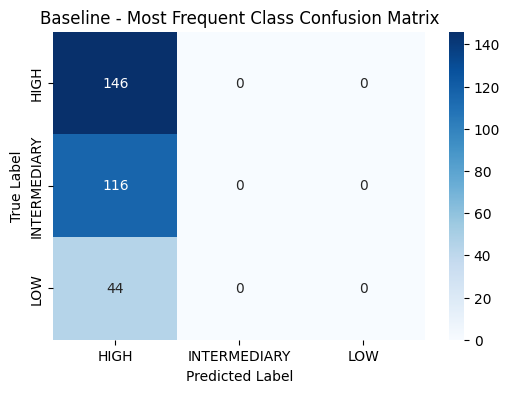

5-Fold CV Macro F1 Scores: [0.2155 0.2155 0.2142 0.2148 0.2148]
Mean CV Macro F1: 0.215


In [ ]:
baseline_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DummyClassifier(strategy='most_frequent', random_state=42))
])

baseline_predictions = evaluate_solution(
    'Baseline - Most Frequent Class',
    baseline_pipeline,
    X_train,
    X_test,
    y_train,
    y_test
)

## 7. Solution 1: Gradient Boosting

This section shows the full workflow for the first solution:
- split training and test data
- preprocess features
- use SelectKBest to select the best features
- train Gradient Boosting
- evaluate accuracy and confusion matrix

Solution 1 - Gradient Boosting
Accuracy: 0.6699
Macro Precision: 0.5183
Macro Recall: 0.5329
Macro F1: 0.5186

Classification Report:
              precision    recall  f1-score   support

        HIGH       0.75      0.82      0.78       146
INTERMEDIARY       0.65      0.72      0.68       116
         LOW       0.16      0.07      0.10        44

    accuracy                           0.67       306
   macro avg       0.52      0.53      0.52       306
weighted avg       0.63      0.67      0.64       306



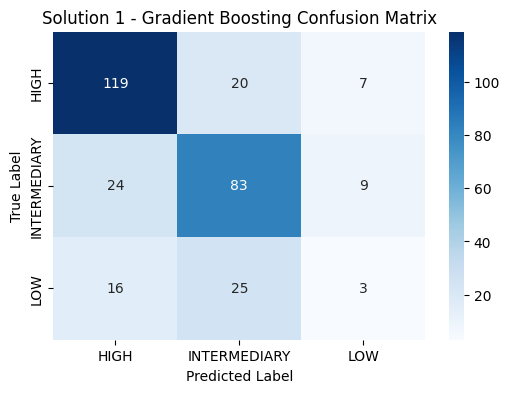

5-Fold CV Macro F1 Scores: [0.4985 0.4811 0.4689 0.5624 0.5123]
Mean CV Macro F1: 0.5046


In [ ]:
gb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('selector', SelectKBest(
        score_func=mutual_info_classif,
        k=20
    )),
    ('model', GradientBoostingClassifier(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.9,
        random_state=42
    ))
])

gb_predictions = evaluate_solution(
    'Solution 1 - Gradient Boosting',
    gb_pipeline,
    X_train,
    X_test,
    y_train,
    y_test
)

### Selected Features for Solution 1

In [ ]:
show_selected_features(gb_pipeline)

Number of selected features: 20


,Selected Feature
0,num__Age
1,num__Weight (kg)
2,num__Height (m)
3,num__BMI
4,num__Total Cholesterol (mg/dL)
5,num__HDL (mg/dL)
6,num__Height (cm)
7,num__Diastolic BP
8,num__Estimated LDL (mg/dL)
9,cat__Sex_F


### Feature Importance for Solution 1

,Feature,Importance
0,num__Age,0.122160
3,num__BMI,0.119012
8,num__Estimated LDL (mg/dL),0.111314
1,num__Weight (kg),0.083053
7,num__Diastolic BP,0.081658
6,num__Height (cm),0.080038
5,num__HDL (mg/dL),0.080008
2,num__Height (m),0.056344
4,num__Total Cholesterol (mg/dL),0.051114
16,cat__Physical Activity Level_Low,0.041116


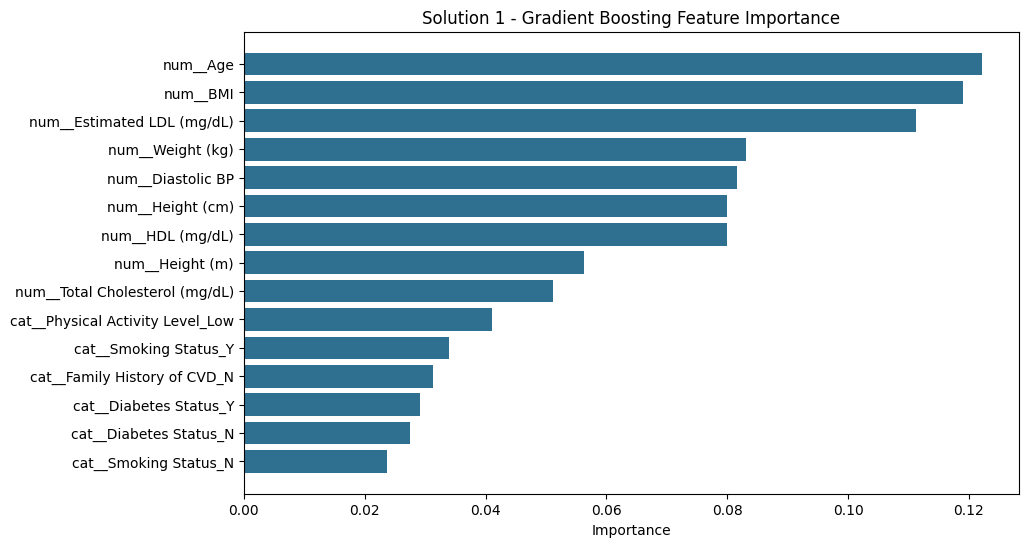

In [ ]:
show_feature_importance(gb_pipeline, 'Solution 1 - Gradient Boosting Feature Importance')

## 8. Solution 2: Random Forest

This section separates the Random Forest solution clearly.

Workflow:
- use the same train/test split for fair comparison
- preprocess the dataset
- select the most useful features
- train Random Forest
- evaluate performance with accuracy, macro F1, and confusion matrix

Solution 2 - Random Forest
Accuracy: 0.6275
Macro Precision: 0.526
Macro Recall: 0.5203
Macro F1: 0.5187

Classification Report:
              precision    recall  f1-score   support

        HIGH       0.69      0.75      0.71       146
INTERMEDIARY       0.63      0.66      0.64       116
         LOW       0.26      0.16      0.20        44

    accuracy                           0.63       306
   macro avg       0.53      0.52      0.52       306
weighted avg       0.60      0.63      0.61       306



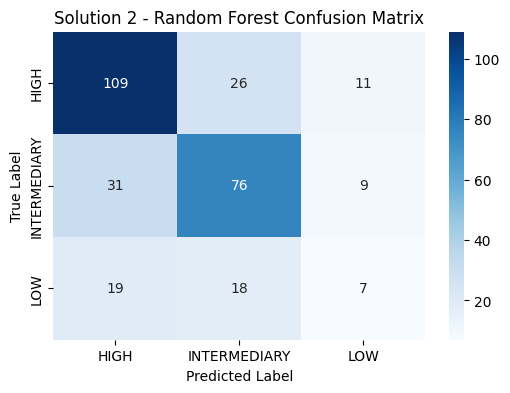

5-Fold CV Macro F1 Scores: [0.5559 0.4428 0.478  0.5403 0.5425]
Mean CV Macro F1: 0.5119


In [ ]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('selector', SelectKBest(score_func=mutual_info_classif, k=20)),
    ('model', RandomForestClassifier(
        n_estimators=300,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

rf_predictions = evaluate_solution(
    'Solution 2 - Random Forest',
    rf_pipeline,
    X_train,
    X_test,
    y_train,
    y_test
)

### Selected Features for Solution 2

In [ ]:
show_selected_features(rf_pipeline)

Number of selected features: 20


,Selected Feature
0,num__Age
1,num__Weight (kg)
2,num__Height (m)
3,num__BMI
4,num__Total Cholesterol (mg/dL)
5,num__HDL (mg/dL)
6,num__Height (cm)
7,num__Waist-to-Height Ratio
8,num__Systolic BP
9,num__Diastolic BP


### Feature Importance for Solution 2

,Feature,Importance
0,num__Age,0.087735
10,num__Estimated LDL (mg/dL),0.083836
6,num__Fasting Blood Sugar (mg/dL),0.080814
9,num__Systolic BP,0.080631
1,num__Weight (kg),0.080335
5,num__HDL (mg/dL),0.078567
3,num__BMI,0.078259
8,num__Waist-to-Height Ratio,0.067579
4,num__Total Cholesterol (mg/dL),0.066711
7,num__Height (cm),0.064818


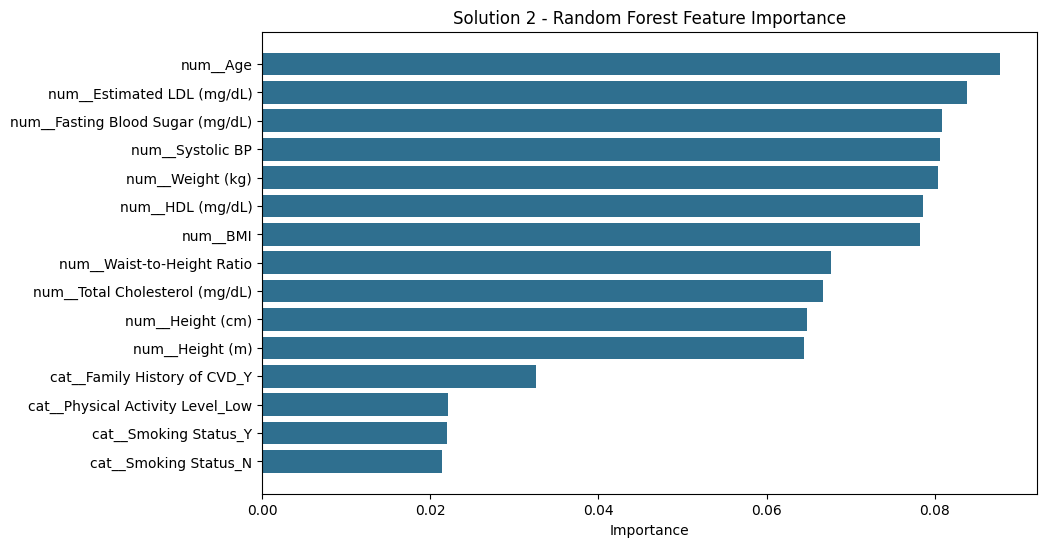

In [ ]:
show_feature_importance(rf_pipeline, 'Solution 2 - Random Forest Feature Importance')

## 9. Final Comparison Table

In [ ]:
comparison = pd.DataFrame([
    {
        'Model': 'Baseline - Most Frequent',
        'Accuracy': accuracy_score(y_test, baseline_predictions),
        'Macro Precision': precision_score(y_test, baseline_predictions, average='macro', zero_division=0),
        'Macro Recall': recall_score(y_test, baseline_predictions, average='macro', zero_division=0),
        'Macro F1': f1_score(y_test, baseline_predictions, average='macro')
    },
    {
        'Model': 'Gradient Boosting',
        'Accuracy': accuracy_score(y_test, gb_predictions),
        'Macro Precision': precision_score(y_test, gb_predictions, average='macro', zero_division=0),
        'Macro Recall': recall_score(y_test, gb_predictions, average='macro', zero_division=0),
        'Macro F1': f1_score(y_test, gb_predictions, average='macro')
    },
    {
        'Model': 'Random Forest',
        'Accuracy': accuracy_score(y_test, rf_predictions),
        'Macro Precision': precision_score(y_test, rf_predictions, average='macro', zero_division=0),
        'Macro Recall': recall_score(y_test, rf_predictions, average='macro', zero_division=0),
        'Macro F1': f1_score(y_test, rf_predictions, average='macro')
    }
]).sort_values('Macro F1', ascending=False)

comparison

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
2,Random Forest,0.627451,0.526042,0.520280,0.518668
1,Gradient Boosting,0.669935,0.518253,0.532923,0.518631
0,Baseline - Most Frequent,0.477124,0.159041,0.333333,0.215339


## 10. Conclusion

In [ ]:
best_model = comparison.iloc[0]['Model']
print('Best model based on Macro F1:', best_model)
print('\nProject conclusion example:')
print(f'Among the two solutions, {best_model} achieved the best balanced performance for predicting cardiovascular disease risk level on this dataset.')

Best model based on Macro F1: Random Forest

Project conclusion example:
Among the two solutions, Random Forest achieved the best balanced performance for predicting cardiovascular disease risk level on this dataset.


#  Additions: Error Analysis, Integration, and Testing

This section focus on error analysis, reusable inference, validation, testing, and API integration.

## Error Analysis

This section checks which classes are difficult for the model and explains why accuracy alone is not enough. For imbalanced multi-class prediction problems, macro F1 is often more informative because it gives equal weight to each class.

In [ ]:
# Select the final fitted pipeline based on the comparison table.
# The baseline is excluded from final model selection because it is used only as a reference point.
model_lookup = {
    'Gradient Boosting': gb_pipeline,
    'Random Forest': rf_pipeline
}

non_baseline_comparison = comparison[comparison['Model'] != 'Baseline - Most Frequent'].copy()
final_model_name = non_baseline_comparison.iloc[0]['Model']
final_pipeline = model_lookup[final_model_name]
final_predictions = final_pipeline.predict(X_test)

print('Final selected model:', final_model_name)
print('Final model metrics:')
display(non_baseline_comparison.head())

Final selected model: Random Forest
Final model metrics:


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
2,Random Forest,0.627451,0.526042,0.520280,0.518668
1,Gradient Boosting,0.669935,0.518253,0.532923,0.518631


In [ ]:

report_dict = classification_report(y_test, final_predictions, output_dict=True, zero_division=0)

class_rows = []
for label, metrics in report_dict.items():
    if label in ['accuracy', 'macro avg', 'weighted avg']:
        continue
    class_rows.append({
        'Class': label,
        'Precision': metrics['precision'],
        'Recall': metrics['recall'],
        'F1-score': metrics['f1-score'],
        'Support': metrics['support']
    })

class_performance = pd.DataFrame(class_rows).sort_values('F1-score')
display(class_performance)

weakest_class = class_performance.iloc[0]['Class']
print(f'Weakest class based on F1-score: {weakest_class}')

,Class,Precision,Recall,F1-score,Support
2,LOW,0.259259,0.159091,0.197183,44.0
1,INTERMEDIARY,0.633333,0.655172,0.644068,116.0
0,HIGH,0.685535,0.746575,0.714754,146.0


Weakest class based on F1-score: LOW


###  explanation for error analysis


> I evaluated the model using macro F1 because the classes are not equally easy to predict. Accuracy gives a general result, but macro F1 shows whether the model performs consistently across LOW, INTERMEDIARY, and HIGH risk groups. The weakest class deserves additional analysis because it may indicate class imbalance, overlapping feature patterns, or limited signal in the dataset.

Possible improvements:
- add more data for the weakest class
- tune model hyperparameters
- test class-imbalance strategies
- review whether the target labels were generated from a risk formula
- perform feature engineering using clinically meaningful variables
- evaluate calibration and prediction confidence

## Optional Hyperparameter Tuning Example

This cell shows how the project could be extended with a small grid search. It is intentionally compact so it can run in Colab. You do not need to run this during the interview, but you can explain that this is how you would tune the model systematically.

In [ ]:
# Optional: compact GridSearchCV for Gradient Boosting


run_grid_search = False

if run_grid_search:
    gb_tuning_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('selector', SelectKBest(score_func=mutual_info_classif, k=20)),
        ('model', GradientBoostingClassifier(random_state=42))
    ])

    param_grid = {
        'selector__k': [10, 20, 'all'],
        'model__n_estimators': [100, 200],
        'model__learning_rate': [0.05, 0.1],
        'model__max_depth': [2, 3]
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    grid_search = GridSearchCV(
        gb_tuning_pipeline,
        param_grid=param_grid,
        scoring='f1_macro',
        cv=cv,
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(X_train, y_train)
    print('Best parameters:', grid_search.best_params_)
    print('Best CV macro F1:', round(grid_search.best_score_, 4))

    tuned_predictions = grid_search.predict(X_test)
    print(classification_report(y_test, tuned_predictions, zero_division=0))

## Software Integration Plan

The current project is in Google Colab, which is suitable for experimentation. To use it in a real software system, the trained preprocessing and model steps should be saved as one pipeline and loaded by an application for inference.

A realistic integration design:

1. Train and save the complete scikit-learn pipeline.
2. Load the saved pipeline in an application.
3. Accept patient data as structured input.
4. Validate required fields and basic data types.
5. Return predicted risk level and class probabilities.
6. Add unit tests and integration tests.
7. Monitor model behavior after deployment.

This demonstrates the path from notebook experimentation to production-style software.

In [ ]:
# Save final trained pipeline and basic metadata
model_filename = 'cvd_risk_model_pipeline.joblib'
metadata_filename = 'cvd_risk_model_metadata.json'

joblib.dump(final_pipeline, model_filename)

model_metadata = {
    'project': 'Cardiovascular Disease Risk Prediction',
    'final_model_name': final_model_name,
    'target': TARGET,
    'required_features': X.columns.tolist(),
    'class_labels': sorted(y.unique().tolist()),
    'created_at': datetime.now().isoformat(timespec='seconds'),
    'notes': 'Pipeline includes preprocessing, feature selection, and trained classifier.'
}

with open(metadata_filename, 'w') as file:
    json.dump(model_metadata, file, indent=4)

print(f'Saved model to: {model_filename}')
print(f'Saved metadata to: {metadata_filename}')

Saved model to: cvd_risk_model_pipeline.joblib
Saved metadata to: cvd_risk_model_metadata.json


## Reusable Prediction Function

This function simulates how another software component would use the model. It accepts one patient record as a Python dictionary, validates the input schema, and returns the predicted class plus probabilities.

In [ ]:
# Load model and metadata as a separate application would do
loaded_pipeline = joblib.load(model_filename)

with open(metadata_filename, 'r') as file:
    loaded_metadata = json.load(file)

required_features = loaded_metadata['required_features']
valid_classes = loaded_metadata['class_labels']

print('Required input features:')
for feature in required_features:
    print('-', feature)

Required input features:
- Sex
- Age
- Weight (kg)
- Height (m)
- BMI
- Abdominal Circumference (cm)
- Total Cholesterol (mg/dL)
- HDL (mg/dL)
- Fasting Blood Sugar (mg/dL)
- Smoking Status
- Diabetes Status
- Physical Activity Level
- Family History of CVD
- Height (cm)
- Waist-to-Height Ratio
- Systolic BP
- Diastolic BP
- Blood Pressure Category
- Estimated LDL (mg/dL)


In [ ]:
def validate_patient_input(patient_data, required_features):
    """
    Validate that one patient record contains all required model features.

    This validation is intentionally simple for the notebook. In production,
    stricter validation should include data types, valid ranges, and accepted
    categorical values.
    """
    if not isinstance(patient_data, dict):
        raise TypeError('patient_data must be a dictionary.')

    missing_features = [feature for feature in required_features if feature not in patient_data]
    extra_features = [feature for feature in patient_data if feature not in required_features]

    if missing_features:
        raise ValueError(f'Missing required features: {missing_features}')

    if extra_features:
        print(f'Warning: extra features will be ignored: {extra_features}')

    return True


def predict_cvd_risk(patient_data):
    """
    Predict cardiovascular disease risk for one patient.

    Returns:
        dict with predicted class and class probabilities.
    """
    validate_patient_input(patient_data, required_features)

    clean_input = {feature: patient_data[feature] for feature in required_features}
    input_df = pd.DataFrame([clean_input])

    predicted_class = loaded_pipeline.predict(input_df)[0]

    result = {
        'predicted_cvd_risk_level': predicted_class
    }

    if hasattr(loaded_pipeline, 'predict_proba'):
        probabilities = loaded_pipeline.predict_proba(input_df)[0]
        class_labels = loaded_pipeline.classes_
        result['class_probabilities'] = {
            str(label): round(float(probability), 4)
            for label, probability in zip(class_labels, probabilities)
        }

    return result

In [ ]:
# Create one realistic sample patient from the test set.
# This avoids hard-coding column names and guarantees that the sample matches the dataset schema.

sample_patient = X_test.iloc[0].to_dict()

prediction_result = predict_cvd_risk(sample_patient)
print('Sample patient prediction:')
print(json.dumps(prediction_result, indent=4))

Sample patient prediction:
{
    "predicted_cvd_risk_level": "INTERMEDIARY",
    "class_probabilities": {
        "HIGH": 0.3675,
        "INTERMEDIARY": 0.5288,
        "LOW": 0.1036
    }
}


## Unit-Style Tests in Colab

These tests are simple, but they show the same thinking used in production software:

- Does the model load successfully?
- Does a valid input return a valid class?
- Does missing input fail clearly?
- Does the prediction response include the expected fields?

In a full repository, these would be moved into a `tests/` folder and run with `pytest`.

In [ ]:
def test_model_loads_successfully():
    model = joblib.load(model_filename)
    assert model is not None, 'Model failed to load.'
    print('test_model_loads_successfully passed')


def test_valid_prediction_returns_known_class():
    result = predict_cvd_risk(sample_patient)
    assert result['predicted_cvd_risk_level'] in valid_classes, 'Prediction is not one of the known classes.'
    print('test_valid_prediction_returns_known_class passed')


def test_missing_feature_detection():
    incomplete_patient = sample_patient.copy()
    feature_to_remove = required_features[0]
    incomplete_patient.pop(feature_to_remove, None)

    try:
        predict_cvd_risk(incomplete_patient)
        raise AssertionError('Expected ValueError for missing feature, but no error was raised.')
    except ValueError:
        print('test_missing_feature_detection passed')


def test_prediction_response_schema():
    result = predict_cvd_risk(sample_patient)
    assert 'predicted_cvd_risk_level' in result, 'Missing predicted_cvd_risk_level in response.'
    if 'class_probabilities' in result:
        assert isinstance(result['class_probabilities'], dict), 'class_probabilities must be a dictionary.'
    print('test_prediction_response_schema passed')


test_model_loads_successfully()
test_valid_prediction_returns_known_class()
test_missing_feature_detection()
test_prediction_response_schema()

test_model_loads_successfully passed
test_valid_prediction_returns_known_class passed
test_missing_feature_detection passed
test_prediction_response_schema passed


## Example FastAPI Integration

The code below is an example of how this model could be served as a REST API.
> The model can be saved as a pipeline and loaded by a FastAPI service. A client sends patient data as JSON to `/predict`, and the API returns the predicted risk level and class probabilities. In production, I would add stricter input validation, logging, authentication, and monitoring.

In [ ]:
# Example FastAPI application code.
# Save this as app.py in a normal Python project if you want to deploy it.
# This cell is for demonstration and interview discussion.

fastapi_example = r"""
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, Field
from typing import Dict, Any
import pandas as pd
import joblib
import json

app = FastAPI(title="CVD Risk Prediction API")

model = joblib.load("cvd_risk_model_pipeline.joblib")

with open("cvd_risk_model_metadata.json", "r") as file:
    metadata = json.load(file)

required_features = metadata["required_features"]

class PatientInput(BaseModel):
    # Flexible schema because exact feature names depend on the dataset.
    # A stricter production version should define each field explicitly.
    features: Dict[str, Any] = Field(..., description="Patient feature dictionary")

@app.get("/")
def health_check():
    return {"status": "ok", "model": metadata["final_model_name"]}

@app.post("/predict")
def predict(patient: PatientInput):
    missing = [feature for feature in required_features if feature not in patient.features]
    if missing:
        raise HTTPException(status_code=400, detail={"missing_features": missing})

    clean_input = {feature: patient.features[feature] for feature in required_features}
    input_df = pd.DataFrame([clean_input])

    predicted_class = model.predict(input_df)[0]
    response = {"predicted_cvd_risk_level": str(predicted_class)}

    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(input_df)[0]
        response["class_probabilities"] = {
            str(label): round(float(prob), 4)
            for label, prob in zip(model.classes_, probabilities)
        }

    return response
"""

print(fastapi_example)


from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, Field
from typing import Dict, Any
import pandas as pd
import joblib
import json

app = FastAPI(title="CVD Risk Prediction API")

model = joblib.load("cvd_risk_model_pipeline.joblib")

with open("cvd_risk_model_metadata.json", "r") as file:
    metadata = json.load(file)

required_features = metadata["required_features"]

class PatientInput(BaseModel):
    # Flexible schema because exact feature names depend on the dataset.
    # A stricter production version should define each field explicitly.
    features: Dict[str, Any] = Field(..., description="Patient feature dictionary")

@app.get("/")
def health_check():
    return {"status": "ok", "model": metadata["final_model_name"]}

@app.post("/predict")
def predict(patient: PatientInput):
    missing = [feature for feature in required_features if feature not in patient.features]
    if missing:
        raise HTTPException(status_code=400, detail={"missing_features

## Production Considerations and Limitations

If this project were converted into a real application, the following issues would need to be addressed:

1. **Clinical validation:** this model should not be used for medical decision-making without validation by medical experts.
2. **Target-label validation:** confirm how `CVD Risk Level` was created and whether it is independent from the input features.
3. **Data quality:** validate missing values, unrealistic ranges, and invalid categories.
4. **Class imbalance:** review performance by class and improve weak-class recall.
5. **Fairness:** compare performance across demographic groups such as age and gender where appropriate.
6. **Security and privacy:** health-related data requires careful access control, storage, and transmission.
7. **Monitoring:** track prediction distributions and performance drift after deployment.
8. **Testing:** maintain unit tests, integration tests, and reproducibility checks.

This is the key interview point: the project is not only a notebook; it has a clear path toward software integration.